# ᄅ Lab 42: Feature Extraction with BoW and TF-IDF

## ᄅ Purpose

In this lab, you will learn how to convert raw text into numerical features that machine learning models can understand. Text itself cannot be used directly by most classical machine learning algorithms, so we need feature extraction techniques such as **Bag of Words (BoW)** and **Term Frequency-Inverse Document Frequency (TF-IDF)**.

You will start by understanding the concepts, then implement them using scikit-learn, compare sparse and dense representations, work with unigrams and bigrams, use the extracted features for sentiment classification, analyze feature importance, and review best practices for real-world NLP pipelines.

---

## ᄅ Learning Objectives

By the end of this lab, students will be able to:

* Understand the concepts of Bag of Words (BoW) and TF-IDF.
* Implement text vectorization using `CountVectorizer` and `TfidfVectorizer`.
* Compare dense and sparse matrix representations.
* Visualize the most frequent words and bigrams in text data.
* Evaluate different feature extraction methods for classification tasks.
* Apply BoW and TF-IDF to a simple sentiment analysis problem.
* Analyze which features contribute most to model predictions.
* Explore parameter tuning and best practices for text vectorization.

---

## ᄅ Prerequisites

Before starting this lab, students should have:

* Basic understanding of Python programming.
* Familiarity with pandas and numpy.
* Basic understanding of text preprocessing.
* Introductory knowledge of machine learning concepts.
* Basic experience with matplotlib and seaborn.

---

## ᄅ Target Environment

This completed lab is written for **Google Colab**.

That means:
* all code runs in notebook cells
* packages are installed with `!pip install`
* any datasets used in the lab are created directly in the notebook
* plots render inline
* no local Linux or VM setup is required

## ᄅ 1. Environment Setup

### ELI10
Before doing any analysis, we need to load the tools (libraries) that will help us turn text into vectors, train models, and create charts. Think of this as gathering your ingredients before cooking.

In [1]:
# Install required libraries
!pip -q install pandas numpy matplotlib seaborn scikit-learn wordcloud

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Configure plotting style
plt.style.use("default")
sns.set_palette("husl")

print("Libraries imported successfully.")

Libraries imported successfully.


## ᄅ 2. Creating the Dataset

### ELI10
We need some text to practice on. We will create a small collection of movie reviews and label them as either positive (1) or negative (0). This will be our 'toy' dataset.

In [2]:
# Create sample dataset
sample_reviews = [
    "This movie is absolutely fantastic and amazing",
    "I loved this film, it was great and wonderful",
    "Terrible movie, very bad and disappointing",
    "Amazing cinematography and excellent acting performance",
    "Boring film with poor storyline and bad acting",
    "Outstanding movie with brilliant direction and script",
    "Worst movie ever, completely waste of time",
    "Incredible story with fantastic visual effects",
    "Poor quality film with terrible sound effects",
    "Excellent movie with great character development",
    "Awful acting and boring plot throughout",
    "Masterpiece with outstanding performances by all actors",
    "Disappointing film with weak storyline and direction",
    "Brilliant movie with amazing special effects",
    "Terrible script and poor character development"
]

labels = [1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

# Create DataFrame
df = pd.DataFrame({"review": sample_reviews, "sentiment": labels})

# Save to CSV
df.to_csv("movie_reviews.csv", index=False)

# Display data stats
print(f"Dataset Shape: {df.shape}")
print(f"Positive Reviews: {df['sentiment'].sum()}")
print(f"Negative Reviews: {len(df) - df['sentiment'].sum()}")
display(df.head(10))

Dataset Shape: (15, 2)
Positive Reviews: 8
Negative Reviews: 7


,review,sentiment
0,This movie is absolutely fantastic and amazing,1
1,"I loved this film, it was great and wonderful",1
2,"Terrible movie, very bad and disappointing",0
3,Amazing cinematography and excellent acting pe...,1
4,Boring film with poor storyline and bad acting,0
5,Outstanding movie with brilliant direction and...,1
6,"Worst movie ever, completely waste of time",0
7,Incredible story with fantastic visual effects,1
8,Poor quality film with terrible sound effects,0
9,Excellent movie with great character development,1


## ᄅ 3. Understanding Feature Extraction Concepts

### ELI10
Computers don't read words; they read numbers. Feature extraction is the process of turning sentences into a grid of numbers.

*   **Bag of Words (BoW):** Imagine throwing all the words from a review into a bag and counting how many times each word appears. We lose the order but keep the counts.
*   **TF-IDF:** This stands for *Term Frequency-Inverse Document Frequency*. It's a score that says: 'How important is this word to this specific document compared to all other documents?' It helps highlight unique, meaningful words like 'cinematography' over common ones like 'is'.

## ᄅ 4. Bag of Words Vectorization

### ELI10
Now we'll use a tool called `CountVectorizer` to build our bag. We will remove 'stop words' (boring words like 'and', 'the') because they don't help us tell if a movie is good or bad.

In [3]:
# Initialize CountVectorizer
bow_vectorizer = CountVectorizer(lowercase=True, stop_words="english", max_features=100)

# Fit and transform the reviews
bow_matrix = bow_vectorizer.fit_transform(df["review"])

# Inspect matrix properties
print(f"Matrix Shape: {bow_matrix.shape} (15 reviews, unique words)")
print(f"Matrix Type: {type(bow_matrix)}")
print(f"Vocabulary Size: {len(bow_vectorizer.get_feature_names_out())}")
print(f"First 20 Features: {bow_vectorizer.get_feature_names_out()[:20]}")

# Create a dense DataFrame for visibility
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())

# Calculate word frequencies
word_freq = bow_df.sum().sort_values(ascending=False)
word_freq_df = pd.DataFrame({"word": word_freq.index, "frequency": word_freq.values})

print("\nTop 15 Most Frequent Words:")
display(word_freq_df.head(15))

Matrix Shape: (15, 41) (15 reviews, unique words)
Matrix Type: <class 'scipy.sparse._csr.csr_matrix'>
Vocabulary Size: 41
First 20 Features: ['absolutely' 'acting' 'actors' 'amazing' 'awful' 'bad' 'boring'
 'brilliant' 'character' 'cinematography' 'completely' 'development'
 'direction' 'disappointing' 'effects' 'excellent' 'fantastic' 'film'
 'great' 'incredible']

Top 15 Most Frequent Words:


,word,frequency
0,movie,6
1,film,4
2,effects,3
3,amazing,3
4,terrible,3
5,poor,3
6,acting,3
7,boring,2
8,brilliant,2
9,outstanding,2


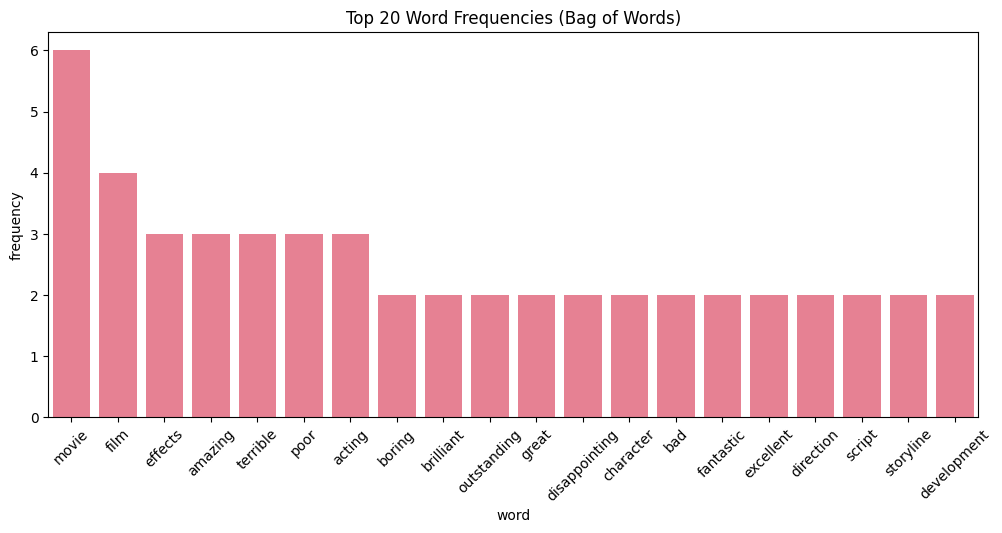

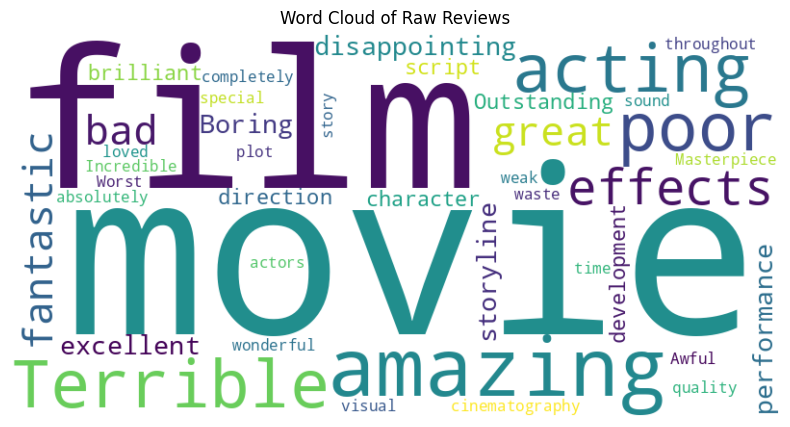

In [4]:
# Visualize BoW
plt.figure(figsize=(12, 5))
sns.barplot(data=word_freq_df.head(20), x='word', y='frequency')
plt.title("Top 20 Word Frequencies (Bag of Words)")
plt.xticks(rotation=45)
plt.show()

# Word Cloud
wc = WordCloud(width=800, height=400, background_color='white').generate(" ".join(df['review']))
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Raw Reviews")
plt.show()

## ᄅ 5. TF-IDF Vectorization

### ELI10
Let's see how TF-IDF compares. Instead of just counts, we get decimal scores. A high score means a word is very characteristic of that specific review.

In [5]:
# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(lowercase=True, stop_words="english", max_features=100, ngram_range=(1, 1))
tfidf_matrix = tfidf_vectorizer.fit_transform(df["review"])

# Convert to dense for analysis
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
mean_tfidf = tfidf_df.mean().sort_values(ascending=False)

# Comparison DataFrame
comparison_df = pd.DataFrame({
    "word": word_freq_df["word"],
    "bow_frequency": word_freq_df["frequency"]
}).merge(pd.DataFrame({"word": mean_tfidf.index, "tfidf_mean": mean_tfidf.values}), on="word")

print("BoW Frequency vs Mean TF-IDF (Top 15):")
display(comparison_df.head(15))

# Document inspection
print("\nTop TF-IDF words for the first 5 reviews:")
for i in range(5):
    top_words = tfidf_df.iloc[i].sort_values(ascending=False).head(5)
    print(f"Review {i+1}: {list(top_words.index)}")

BoW Frequency vs Mean TF-IDF (Top 15):


,word,bow_frequency,tfidf_mean
0,movie,6,0.133051
1,film,4,0.096293
2,effects,3,0.078093
3,amazing,3,0.085789
4,terrible,3,0.085624
5,poor,3,0.078661
6,acting,3,0.080156
7,boring,2,0.060710
8,brilliant,2,0.063378
9,outstanding,2,0.061422



Top TF-IDF words for the first 5 reviews:
Review 1: ['absolutely', 'fantastic', 'amazing', 'movie', 'acting']
Review 2: ['loved', 'wonderful', 'great', 'film', 'awful']
Review 3: ['bad', 'disappointing', 'terrible', 'movie', 'absolutely']
Review 4: ['cinematography', 'performance', 'excellent', 'amazing', 'acting']
Review 5: ['boring', 'bad', 'storyline', 'poor', 'acting']


## ᄅ 6. Dense vs Sparse Representations

### ELI10
In NLP, most of our matrix is full of zeros. A 'Sparse' matrix only remembers where the non-zero numbers are to save space. A 'Dense' matrix writes down every single zero, which uses a lot of memory!

BoW Non-zero counts: 72
Total cells: 615
Sparsity Percentage: 88.29%


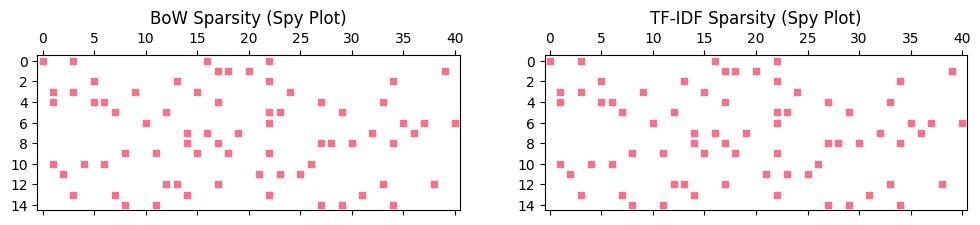

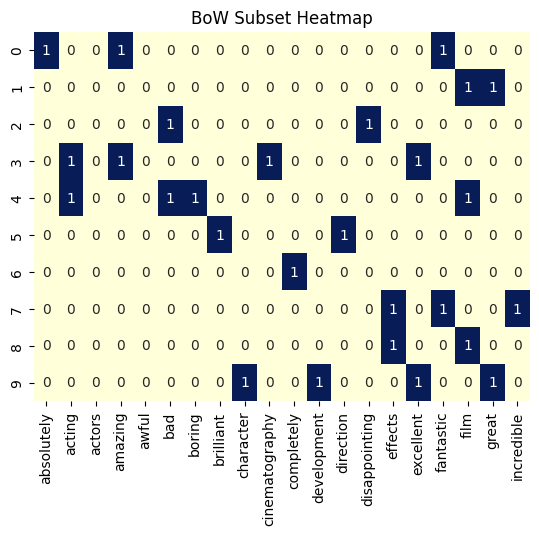

In [6]:
# Calculate stats
total_cells = bow_matrix.shape[0] * bow_matrix.shape[1]
non_zeros = bow_matrix.nnz
sparsity = (1 - non_zeros / total_cells) * 100

print(f"BoW Non-zero counts: {non_zeros}")
print(f"Total cells: {total_cells}")
print(f"Sparsity Percentage: {sparsity:.2f}%")

# Spy plot to visualize sparsity
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.spy(bow_matrix, markersize=5)
ax1.set_title("BoW Sparsity (Spy Plot)")
ax2.spy(tfidf_matrix, markersize=5)
ax2.set_title("TF-IDF Sparsity (Spy Plot)")
plt.show()

# Heatmap of first 10 docs, 20 features
sns.heatmap(bow_df.iloc[:10, :20], annot=True, cmap="YlGnBu", cbar=False)
plt.title("BoW Subset Heatmap")
plt.show()

## ᄅ 7. Working with N-grams

### ELI10
Sometimes words belong together. 'Bad' is one word, but 'not bad' is two words (a bigram) and has a different meaning. N-grams help us capture these phrases.

Top 15 Bigrams:


,ngram,frequency,type
12,character development,2,bigram
0,absolutely fantastic,1,bigram
2,acting performance,1,bigram
1,acting boring,1,bigram
4,amazing special,1,bigram
5,awful acting,1,bigram
6,bad acting,1,bigram
3,amazing cinematography,1,bigram
7,bad disappointing,1,bigram
8,boring film,1,bigram


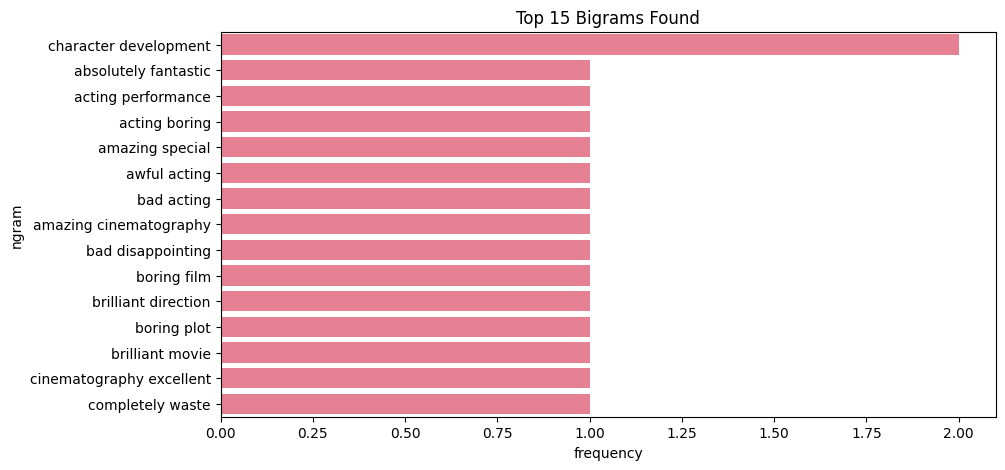

In [7]:
# Bigram Vectorization
bigram_vectorizer = CountVectorizer(ngram_range=(1, 2), stop_words="english", max_features=200)
bigram_matrix = bigram_vectorizer.fit_transform(df["review"])
features = bigram_vectorizer.get_feature_names_out()

# Extract just bigrams
bigram_only_freq = []
counts = bigram_matrix.toarray().sum(axis=0)
for feat, count in zip(features, counts):
    if " " in feat: # It's a bigram
        bigram_only_freq.append({"ngram": feat, "frequency": count, "type": "bigram"})

ngram_df = pd.DataFrame(bigram_only_freq).sort_values("frequency", ascending=False)

print("Top 15 Bigrams:")
display(ngram_df.head(15))

plt.figure(figsize=(10, 5))
sns.barplot(data=ngram_df.head(15), x='frequency', y='ngram')
plt.title("Top 15 Bigrams Found")
plt.show()

## ᄅ 8. Feature Extraction for Classification

### ELI10
Now for the fun part: let's see which method helps a computer predict sentiment best! We'll split our data into a 'study group' (train) and a 'test group' (test).

In [8]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df["review"], df["sentiment"], test_size=0.33, random_state=42, stratify=df["sentiment"]
)

# Dictionary of vectorizers
methods = {
    "BoW": CountVectorizer(stop_words="english", max_features=100),
    "TF-IDF": TfidfVectorizer(stop_words="english", max_features=100),
    "BoW_Bigrams": CountVectorizer(ngram_range=(1, 2), stop_words="english", max_features=200),
    "TF-IDF_Bigrams": TfidfVectorizer(ngram_range=(1, 2), stop_words="english", max_features=200)
}

perf_data = []

for name, vec in methods.items():
    # Transform
    X_tr_vec = vec.fit_transform(X_train)
    X_ts_vec = vec.transform(X_test)

    # Train Naive Bayes
    model = MultinomialNB()
    model.fit(X_tr_vec, y_train)
    y_pred = model.predict(X_ts_vec)

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    perf_data.append({"Method": name, "Accuracy": acc, "Features": X_tr_vec.shape[1]})
    print(f"--- {name} Report ---")
    print(classification_report(y_test, y_pred, zero_division=0))

# Final Comparison
comp_results = pd.DataFrame(perf_data)
display(comp_results)

--- BoW Report ---
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.67      0.67      0.67         3

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5

--- TF-IDF Report ---
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.67      0.67      0.67         3

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5

--- BoW_Bigrams Report ---
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.67      0.67      0.67         3

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weight

,Method,Accuracy,Features
0,BoW,0.6,32
1,TF-IDF,0.6,32
2,BoW_Bigrams,0.6,69
3,TF-IDF_Bigrams,0.6,69


## ᄅ 9. Advanced Feature Analysis

### ELI10
Which words were the biggest 'clues' for positive and negative reviews? We can peek inside the model's brain to find out.

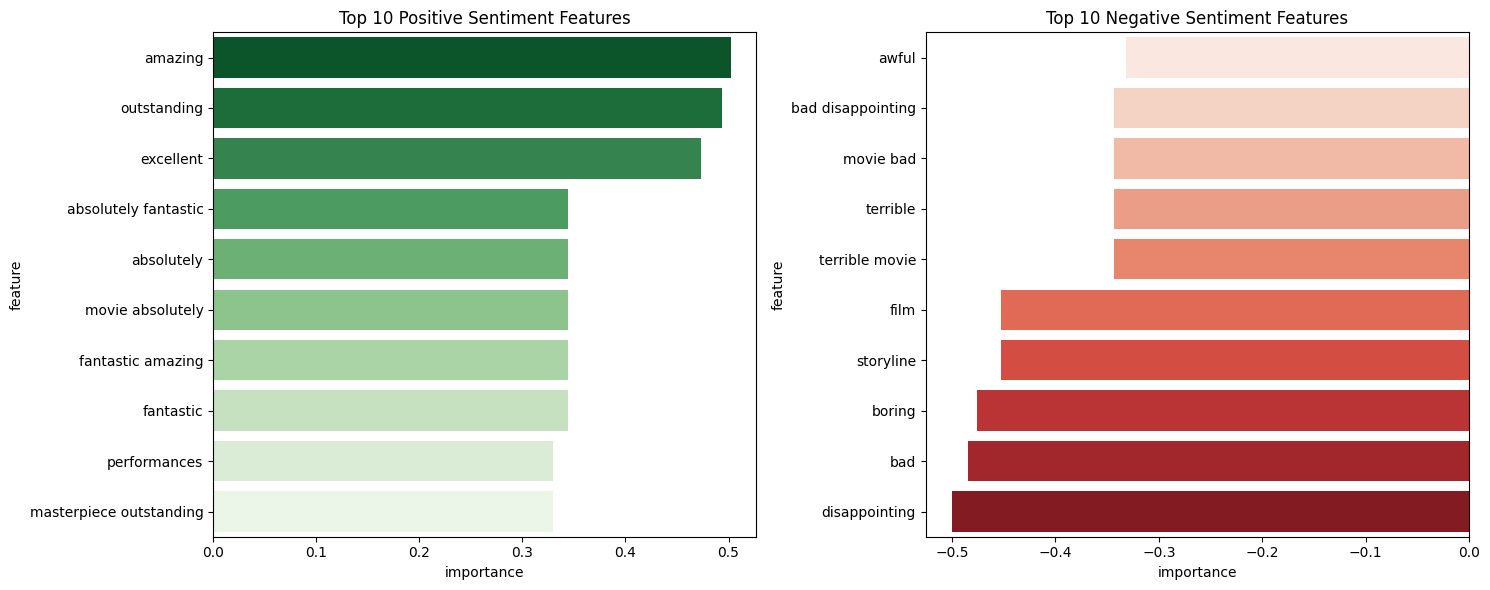

In [9]:
# Using TF-IDF_Bigrams as an example for best potential context
best_vec = methods["TF-IDF_Bigrams"]
best_model = MultinomialNB().fit(best_vec.fit_transform(X_train), y_train)

feature_names = best_vec.get_feature_names_out()
# log prob of features per class
# importance = prob(class 1) - prob(class 0)
importance = best_model.feature_log_prob_[1] - best_model.feature_log_prob_[0]

imp_df = pd.DataFrame({"feature": feature_names, "importance": importance}).sort_values("importance", ascending=False)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=imp_df.head(10), x='importance', y='feature', ax=ax1, palette="Greens_r")
ax1.set_title("Top 10 Positive Sentiment Features")
sns.barplot(data=imp_df.tail(10), x='importance', y='feature', ax=ax2, palette="Reds")
ax2.set_title("Top 10 Negative Sentiment Features")
plt.tight_layout()
plt.show()

## ᄅ 10. Parameter Tuning & Best Practices

### ELI10
Like a radio, we can tune our vectorizers to pick up the signal better. We'll test different vocabulary sizes and phrase lengths.

In [10]:
params = [
    {"max_features": 50, "ngram_range": (1, 1)},
    {"max_features": 100, "ngram_range": (1, 1)},
    {"max_features": 200, "ngram_range": (1, 1)},
    {"max_features": 100, "ngram_range": (1, 2)},
    {"max_features": 200, "ngram_range": (1, 2)},
    {"max_features": 300, "ngram_range": (1, 2)}
]

tuning_list = []
for p in params:
    v = TfidfVectorizer(stop_words="english", **p)
    xtr = v.fit_transform(X_train)
    xts = v.transform(X_test)
    m = MultinomialNB().fit(xtr, y_train)
    acc = accuracy_score(y_test, m.predict(xts))
    tuning_list.append({**p, "Accuracy": acc})

tuning_df = pd.DataFrame(tuning_list).sort_values("Accuracy", ascending=False)
display(tuning_df)

,max_features,ngram_range,Accuracy
0,50,"(1, 1)",0.6
1,100,"(1, 1)",0.6
2,200,"(1, 1)",0.6
3,100,"(1, 2)",0.6
4,200,"(1, 2)",0.6
5,300,"(1, 2)",0.6


## ᄅ Verification

### ELI10
Let's double-check everything is where it should be!

In [11]:
import os
assert os.path.exists("movie_reviews.csv"), "Dataset file missing!"
assert len(df) == 15, "Dataset row count incorrect!"
assert "review" in df.columns, "Column 'review' missing!"
print("\u2705 All verification checks passed!")

✅ All verification checks passed!


## ᄅ Troubleshooting
- **Memory Issues:** If your notebook crashes on large text, reduce `max_features` or keep using sparse matrices (don't use `.toarray()` on 1 million rows!).
- **Vocabulary Mismatch:** Always use `.fit_transform()` on Training data and ONLY `.transform()` on Test data. If you fit on test, the model is 'cheating'.
- **Empty Vocabulary:** If you set `min_df` too high on a small dataset, you might end up with 0 features.

## ᄅ Key Takeaways & What You Learned
- **BoW** is simple counting; **TF-IDF** weights words by uniqueness.
- **Sparsity** is efficient; don't make it dense unless necessary.
- **N-grams** capture context (e.g., 'not good').
- Vectorization is the bridge between human language and machine learning math.

## ᄅ Real-World Importance
These techniques power spam filters, basic search engines, and document sorting systems in almost every major tech company.

## ᄅ Conclusion
You've successfully built an NLP pipeline from scratch! You now know how to turn text into meaningful numbers.

## ᄅ Optional Extension Exercises
1. Try adding your own reviews to the `sample_reviews` list and re-run.
2. Change `stop_words` to None and see how it affects the 'most frequent' words.
3. Try a different classifier like `LogisticRegression` from sklearn.